In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk("/content/kc_house_data.csv"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [2]:
!pip install -q catboost lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [3]:
import plotly.io as pio
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Preprocessing & model utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')


In [4]:
# Upload kc_house_data.csv to the Colab Files panel before running this cell
df = pd.read_csv('/content/kc_house_data.csv')
print(df.shape)
df.head()

(21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
display(df.duplicated().sum())
display(df.isnull().sum())
display(df.info())
df.describe()

np.int64(0)

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

None

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [6]:
# Drop id
df.drop('id', axis=1, inplace=True)
df.drop('zipcode',axis=1, inplace = True)

# Convert date
df['date'] = pd.to_datetime(df['date'].str[:8], format='%Y%m%d')
df['year_sold'] = df['date'].dt.year
df['month_sold'] = df['date'].dt.month
df.drop('date', axis=1, inplace=True)

# Create age of house
df['age'] = df['year_sold'] - df['yr_built']
df['was_renovated'] = (df['yr_renovated'] > 0).astype(int)

# Drop original year columns
df.drop(['yr_built','yr_renovated'], axis=1, inplace=True)


In [7]:
cols_to_cap = ['sqft_lot15', 'sqft_living15', 'long', 'lat',
               'sqft_basement', 'sqft_above', 'sqft_lot',
               'sqft_living', 'bathrooms', 'price', 'bedrooms']

for col in cols_to_cap:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print("Column:", col)
    print("Number of outliers:", len(outliers))
    print(outliers[col])
    print()

Column: sqft_lot15
Number of outliers: 2194
5        101930
21        20336
41        30617
49        72513
60        18900
          ...  
21520     74052
21525    107498
21532     50447
21548    151081
21576     18270
Name: sqft_lot15, Length: 2194, dtype: int64

Column: sqft_living15
Number of outliers: 544
5        4760
21       4110
173      3740
216      3836
269      3890
         ... 
21525    4650
21540    5790
21548    3860
21551    3990
21590    4560
Name: sqft_living15, Length: 544, dtype: int64

Column: long
Number of outliers: 256
99      -121.714
252     -121.711
258     -121.772
365     -121.709
403     -121.779
          ...   
21344   -121.779
21348   -121.769
21382   -121.769
21386   -121.403
21548   -121.778
Name: long, Length: 256, dtype: float64

Column: lat
Number of outliers: 2
3295     47.1559
15599    47.1593
Name: lat, dtype: float64

Column: sqft_basement
Number of outliers: 496
5        1530
10       1700
41       1620
51       1510
69       1600
         .

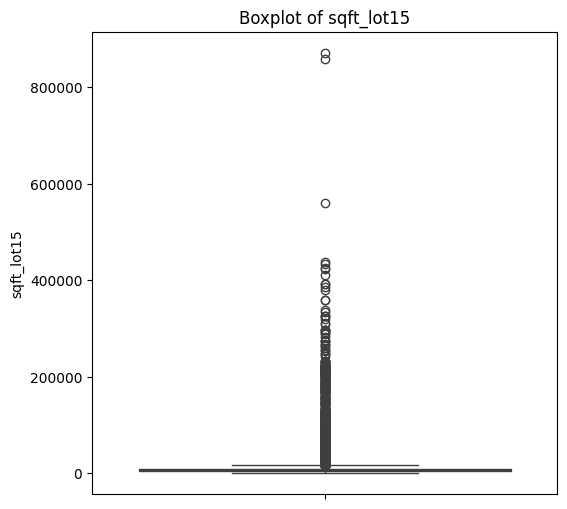

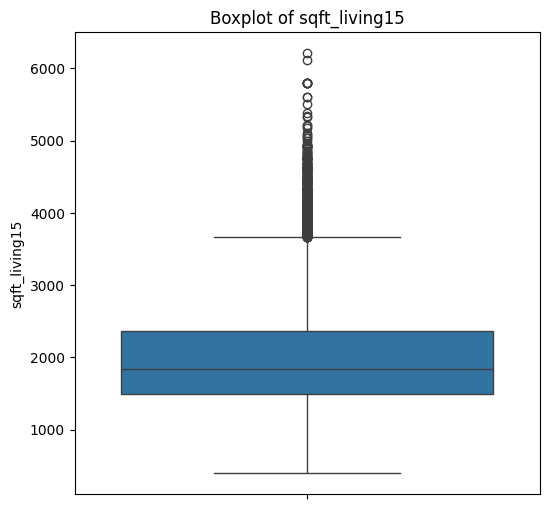

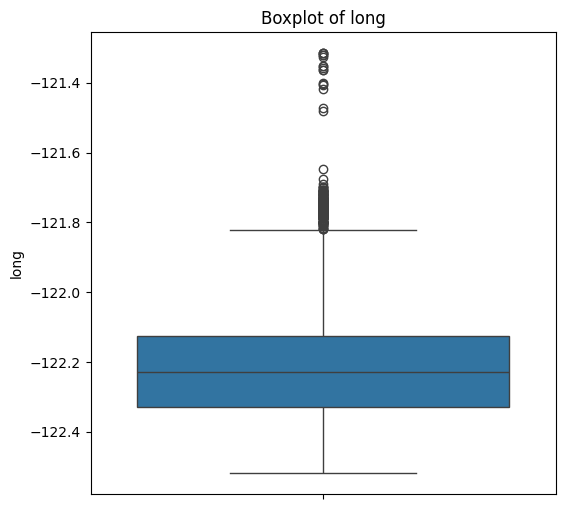

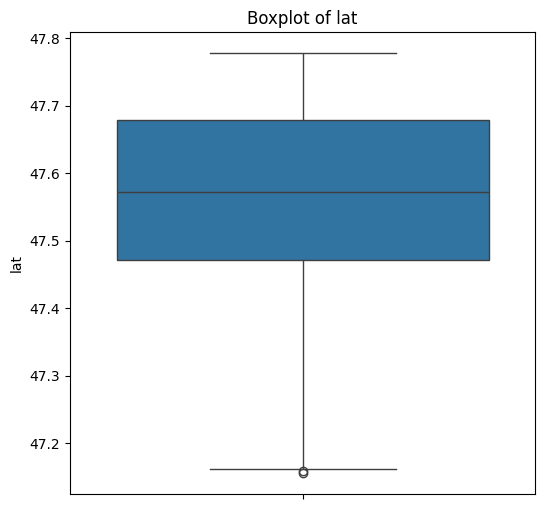

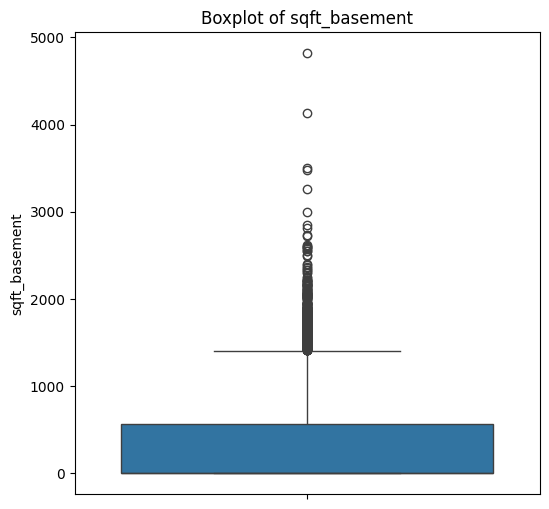

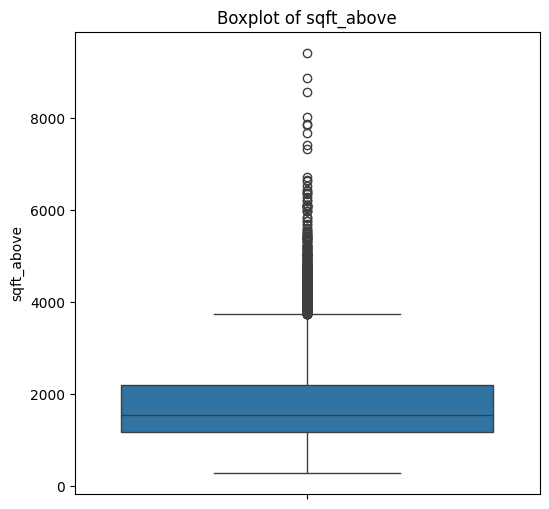

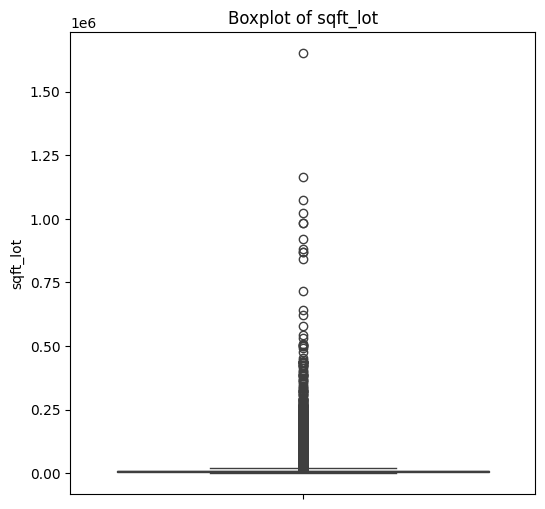

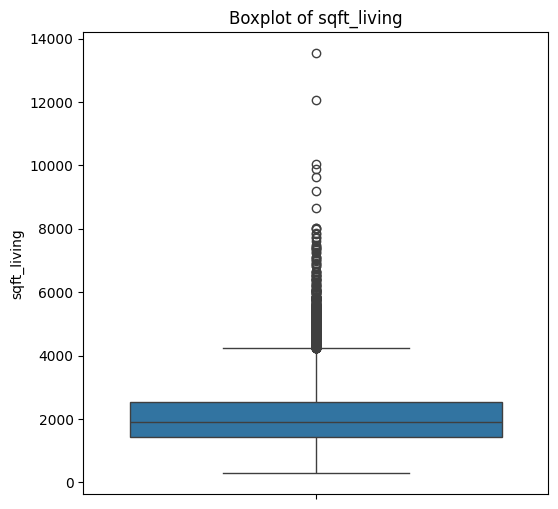

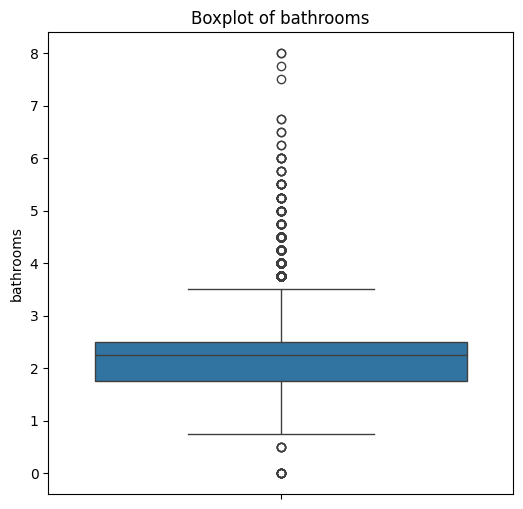

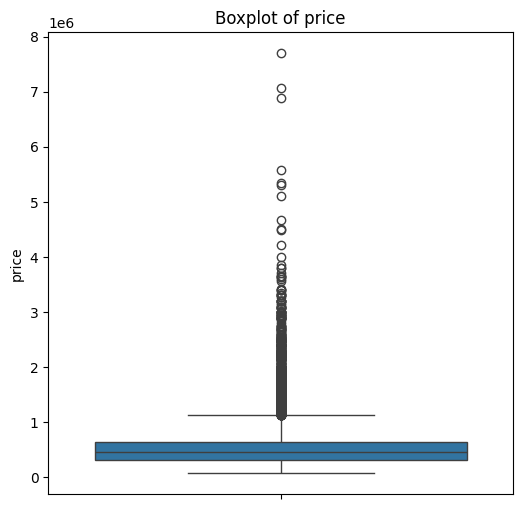

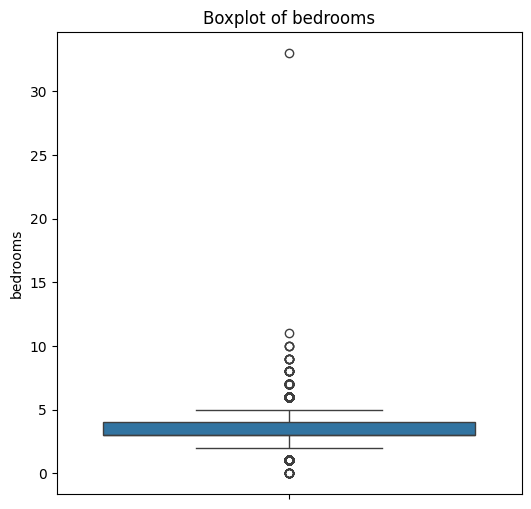

In [8]:
for col in cols_to_cap:

    plt.figure(figsize=(6, 6))

    sns.boxplot(data=df, y=col)

    plt.title(f'Boxplot of {col}')

    plt.show()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  lat            21613 non-null  float64
 13  long           21613 non-null  float64
 14  sqft_living15  21613 non-null  int64  
 15  sqft_lot15     21613 non-null  int64  
 16  year_sold      21613 non-null  int32  
 17  month_sold     21613 non-null  int32  
 18  age   

In [ ]:
# Drop selected features before creating x_train and x_test
df = df.drop(columns=['sqft_lot15', 'condition'], errors='ignore')

# Features and target
x = df.drop('price', axis=1)
y = df['price']

# Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = MinMaxScaler()

# Scale the entire DataFrame (all columns are numeric)
x_train[x_train.columns] = scaler.fit_transform(x_train)
x_test[x_test.columns] = scaler.transform(x_test)